In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df = pd.read_csv(r'..\data\market_daily.csv')

In [35]:
df.head(5)

,Ngày,BTC_USD,USD_VND,VN_Index,standard_time,Gold_Price
0,2015-01-01,313.9,21370.0,NaN,2015-01-01,35.05
1,2015-01-02,315.1,21370.0,NaN,NaN,NaN
2,2015-01-03,282.0,NaN,NaN,NaN,NaN
3,2015-01-04,258.8,NaN,NaN,2015-01-04,35.16
4,2015-01-05,273.2,21370.0,544.45,NaN,NaN


In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4065 entries, 0 to 4064
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Ngày           4061 non-null   str    
 1   BTC_USD        4063 non-null   float64
 2   USD_VND        2905 non-null   float64
 3   VN_Index       2776 non-null   float64
 4   standard_time  2918 non-null   str    
 5   Gold_Price     2918 non-null   float64
dtypes: float64(4), str(2)
memory usage: 190.7 KB


In [37]:
df.describe()

,BTC_USD,USD_VND,VN_Index,Gold_Price
count,4063.000000,2905.000000,2776.000000,2918.000000
mean,28246.724317,23456.775215,1031.279856,49.912872
std,32252.978030,1204.385187,301.991684,15.812185
min,183.000000,21115.000000,521.880000,32.450000
25%,3820.250000,22715.000000,786.665000,36.425000
50%,11518.000000,23184.000000,1011.730000,41.837500
75%,43811.500000,23725.000000,1250.327500,66.487500
max,126110.000000,26457.000000,1902.930000,96.200000


Records by Month:
year_month
2015-01    25
2015-02    17
2015-03    26
2015-04    23
2015-05    26
           ..
2024-09    21
2024-10    26
2024-11    10
2024-12     8
2025-03     2
Freq: M, Length: 121, dtype: int64

Total months: 121


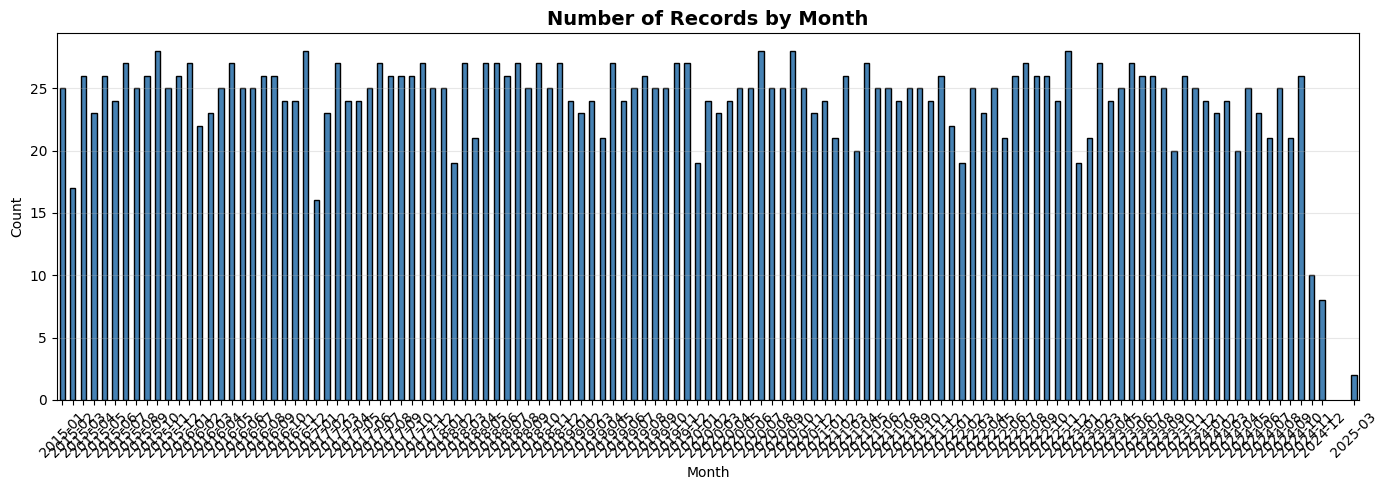

In [38]:
# check number of records by month
df['standard_time'] = pd.to_datetime(df['standard_time'])
df['year_month'] = df['standard_time'].dt.to_period('M')

# Records by month
monthly_count = df.groupby('year_month').size()
print("Records by Month:")
print(monthly_count)
print(f"\nTotal months: {len(monthly_count)}")

# Visualization
plt.figure(figsize=(14, 5))
monthly_count.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Number of Records by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
df[df['Ngày'].isnull() & (df['standard_time'].isnull() ==False)]

,Ngày,BTC_USD,USD_VND,VN_Index,standard_time,Gold_Price,year_month


In [40]:
df.drop(columns='Ngày', inplace=True) 

In [41]:
df.head(5)

,BTC_USD,USD_VND,VN_Index,standard_time,Gold_Price,year_month
0,313.9,21370.0,NaN,2015-01-01,35.05,2015-01
1,315.1,21370.0,NaN,NaT,NaN,NaT
2,282.0,NaN,NaN,NaT,NaN,NaT
3,258.8,NaN,NaN,2015-01-04,35.16,2015-01
4,273.2,21370.0,544.45,NaT,NaN,NaT


In [42]:
df.dropna(subset=['standard_time'], inplace=True)

In [43]:
df = df[df['standard_time'] <= pd.to_datetime('2024-10-31')]

In [44]:
df

,BTC_USD,USD_VND,VN_Index,standard_time,Gold_Price,year_month
0,313.9,21370.0,NaN,2015-01-01,35.05,2015-01
3,258.8,NaN,NaN,2015-01-04,35.16,2015-01
5,285.4,21420.0,549.66,2015-01-06,34.90,2015-01
6,297.0,21420.0,552.05,2015-01-07,34.38,2015-01
7,285.6,21360.0,553.47,2015-01-08,33.05,2015-01
...,...,...,...,...,...,...
3584,67081.0,NaN,NaN,2024-10-26,88.00,2024-10
3585,68035.0,NaN,NaN,2024-10-27,88.00,2024-10
3586,69989.0,25345.0,1254.77,2024-10-28,88.00,2024-10
3587,72688.0,25295.0,1261.78,2024-10-29,88.00,2024-10


In [45]:
df.dropna(subset=['VN_Index'], inplace=True)

In [46]:
df

,BTC_USD,USD_VND,VN_Index,standard_time,Gold_Price,year_month
5,285.4,21420.0,549.66,2015-01-06,34.90,2015-01
6,297.0,21420.0,552.05,2015-01-07,34.38,2015-01
7,285.6,21360.0,553.47,2015-01-08,33.05,2015-01
8,292.8,21340.0,569.73,2015-01-09,34.30,2015-01
11,267.6,21315.0,574.32,2015-01-12,33.01,2015-01
...,...,...,...,...,...,...
3582,68188.0,25385.0,1257.41,2024-10-24,88.00,2024-10
3583,66734.0,25355.0,1252.72,2024-10-25,88.00,2024-10
3586,69989.0,25345.0,1254.77,2024-10-28,88.00,2024-10
3587,72688.0,25295.0,1261.78,2024-10-29,88.00,2024-10


In [47]:
df.info()

<class 'pandas.DataFrame'>
Index: 2246 entries, 5 to 3589
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   BTC_USD        2246 non-null   float64       
 1   USD_VND        2246 non-null   float64       
 2   VN_Index       2246 non-null   float64       
 3   standard_time  2246 non-null   datetime64[us]
 4   Gold_Price     2246 non-null   float64       
 5   year_month     2246 non-null   period[M]     
dtypes: datetime64[us](1), float64(4), period[M](1)
memory usage: 122.8 KB


In [48]:
# convert to datetime and set index
df['standard_time'] = pd.to_datetime(df['standard_time'])
df.set_index('standard_time', inplace=True)

In [52]:
# convert unit of Gold price from million VND/tael to VND/tael
df['Gold_Price'] = df['Gold_Price'] * 1e6

In [53]:
def prepare_data(df):
    # Convert BTC/USD to BTC/VND
    df["BTC_VND"] = df["BTC_USD"] * df["USD_VND"]

    price = df[["VN_Index", "Gold_Price", "BTC_VND", "BTC_USD", "USD_VND"]].dropna()

    log_price = np.log(price)
    log_price.columns = [
        "ln_vnindex",
        "ln_gold",
        "ln_btc_vnd",
        "ln_btc_usd",
        "ln_usdvnd"
    ]

    ret = log_price.diff().dropna()
    ret.columns = [
        "r_vnindex",
        "r_gold",
        "r_btc_vnd",
        "r_btc_usd",
        "r_usdvnd"
    ]

    return price, log_price, ret

price, log_price, ret = prepare_data(df)

In [54]:
for data in [price, log_price, ret]:
    print(data.head())

               VN_Index  Gold_Price    BTC_VND  BTC_USD  USD_VND
standard_time                                                   
2015-01-06       549.66  34900000.0  6113268.0    285.4  21420.0
2015-01-07       552.05  34380000.0  6361740.0    297.0  21420.0
2015-01-08       553.47  33050000.0  6100416.0    285.6  21360.0
2015-01-09       569.73  34300000.0  6248352.0    292.8  21340.0
2015-01-12       574.32  33010000.0  5703894.0    267.6  21315.0
               ln_vnindex    ln_gold  ln_btc_vnd  ln_btc_usd  ln_usdvnd
standard_time                                                          
2015-01-06       6.309300  17.367997   15.625972    5.653892   9.972080
2015-01-07       6.313639  17.352986   15.665812    5.693732   9.972080
2015-01-08       6.316208  17.313532   15.623868    5.654592   9.969275
2015-01-09       6.345163  17.350656   15.647828    5.679490   9.968339
2015-01-12       6.353187  17.312321   15.556660    5.589493   9.967166
               r_vnindex    r_gold  r_btc